
Import library yang dibutuhkan untuk analisis data (pandas, numpy) dan visualisasi
(matplotlib, seaborn). Dataset dimuat dari file CSV menggunakan `pandas.read_csv()`.




In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("mushrooms.csv")
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


Lima baris pertama dataset di atas menunjukkan gambaran awal struktur data: setiap baris
merepresentasikan satu sampel jamur, dengan 23 kolom (1 kolom target `class` + 22 kolom
fitur fisik seperti bentuk topi, warna, bau, dan tekstur). Semua nilai berupa kode huruf
tunggal karena setiap fitur bersifat kategorikal/nominal.

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1


Karena seluruh attribute dalam dataset ini bertipe object (kategorikal), sementara beberapa
kriteria eksplorasi (statistik deskriptif, korelasi) memerlukan data numerik, dilakukan
**Label Encoding** terlebih dahulu — mengubah tiap kategori huruf menjadi angka (misal
b=0, c=1, x=2, dst). Perlu dicatat bahwa angka hasil encoding ini bersifat nominal
(hanya sebagai pengganti kategori), bukan angka dengan makna kuantitatif asli.

In [ ]:
df_encoded.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,...,8124.000000,8124.000000,8124.000000,8124.0,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000
mean,0.482029,3.348104,1.827671,4.504677,0.415559,4.144756,0.974151,0.161497,0.309207,4.810684,...,1.603644,5.816347,5.794682,0.0,1.965534,1.069424,2.291974,3.596750,3.644018,1.508616
std,0.499708,1.604329,1.229873,2.545821,0.492848,2.103729,0.158695,0.368011,0.462195,3.540359,...,0.675974,1.901747,1.907291,0.0,0.242669,0.271064,1.801672,2.382663,1.252082,1.719975
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,3.000000,0.000000,2.000000,1.000000,0.000000,0.000000,2.000000,...,1.000000,6.000000,6.000000,0.0,2.000000,1.000000,0.000000,2.000000,3.000000,0.000000
50%,0.000000,3.000000,2.000000,4.000000,0.000000,5.000000,1.000000,0.000000,0.000000,5.000000,...,2.000000,7.000000,7.000000,0.0,2.000000,1.000000,2.000000,3.000000,4.000000,1.000000
75%,1.000000,5.000000,3.000000,8.000000,1.000000,5.000000,1.000000,0.000000,1.000000,7.000000,...,2.000000,7.000000,7.000000,0.0,2.000000,1.000000,4.000000,7.000000,4.000000,2.000000
max,1.000000,5.000000,3.000000,9.000000,1.000000,8.000000,1.000000,1.000000,1.000000,11.000000,...,3.000000,8.000000,8.000000,0.0,3.000000,2.000000,4.000000,8.000000,5.000000,6.000000


Bagian ini menampilkan ringkasan statistik dari data yang sudah di-encode:
- **mean**: rata-rata kode kategori
- **std**: standar deviasi (sebaran kode kategori)
- **min / max**: kode kategori terkecil dan terbesar
- **25% (Q1)**, **50% (Q2/median)**, **75% (Q3)**: kuartil

Karena data aslinya nominal (bukan ordinal/kontinu), nilai-nilai statistik ini tidak
memiliki makna kuantitatif langsung seperti pada data numerik asli (misalnya tinggi badan
atau harga), namun tetap berguna untuk melihat sebaran dan variasi kategori tiap fitur.

Dari tabel di atas terlihat variasi jumlah kategori pada tiap kolom (tercermin dari nilai
max yang berbeda-beda). Misalnya kolom `veil-type` memiliki nilai max 0, menandakan kolom
ini hanya punya 1 kategori unik di seluruh dataset (tidak informatif untuk klasifikasi).

In [ ]:
df_encoded.head(10)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1
5,0,5,3,9,1,0,1,0,0,5,...,2,7,7,0,2,1,4,2,2,1
6,0,0,2,8,1,0,1,0,0,2,...,2,7,7,0,2,1,4,2,2,3
7,0,0,3,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,3,3
8,1,5,3,8,1,6,1,0,1,7,...,2,7,7,0,2,1,4,2,4,1
9,0,0,2,9,1,0,1,0,0,2,...,2,7,7,0,2,1,4,2,3,3


Menampilkan 10 Record Pertama (Attribute Numerik)

Karena data telah di-encode menjadi angka pada langkah sebelumnya, 10 baris pertama
`df_encoded` dapat langsung ditampilkan sebagai representasi numerik dari dataset.

In [ ]:
print("Jumlah record:", df.shape[0])
print("Jumlah attribute:", df.shape[1])
print("Nama attribute:", list(df.columns))
print("Jumlah attribute numerik (sebelum encoding):", df.select_dtypes(include=np.number).shape[1])
print("Jumlah attribute numerik (setelah encoding):", df_encoded.shape[1])

df.info()

Jumlah record: 8124
Jumlah attribute: 23
Nama attribute: ['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']
Jumlah attribute numerik (sebelum encoding): 0
Jumlah attribute numerik (setelah encoding): 23
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   


Bagian ini menampilkan ringkasan struktur dataset: jumlah baris (record), jumlah kolom
(attribute), nama-nama attribute, serta jumlah attribute numerik (sebelum dan sesudah
encoding).

Dataset ini terdiri dari 8.124 record dan 23 attribute. Sebelum encoding, jumlah attribute
numerik adalah **0** karena seluruh kolom bertipe object (kategorikal). Setelah dilakukan
Label Encoding, seluruh 23 attribute dapat diperlakukan sebagai numerik.

In [ ]:
object_cols = df.select_dtypes(include='object').columns
for col in object_cols:
    print(f"{col}: {df[col].nunique()} label unik -> {sorted(df[col].unique())}")

class: 2 label unik -> ['e', 'p']
cap-shape: 6 label unik -> ['b', 'c', 'f', 'k', 's', 'x']
cap-surface: 4 label unik -> ['f', 'g', 's', 'y']
cap-color: 10 label unik -> ['b', 'c', 'e', 'g', 'n', 'p', 'r', 'u', 'w', 'y']
bruises: 2 label unik -> ['f', 't']
odor: 9 label unik -> ['a', 'c', 'f', 'l', 'm', 'n', 'p', 's', 'y']
gill-attachment: 2 label unik -> ['a', 'f']
gill-spacing: 2 label unik -> ['c', 'w']
gill-size: 2 label unik -> ['b', 'n']
gill-color: 12 label unik -> ['b', 'e', 'g', 'h', 'k', 'n', 'o', 'p', 'r', 'u', 'w', 'y']
stalk-shape: 2 label unik -> ['e', 't']
stalk-root: 5 label unik -> ['?', 'b', 'c', 'e', 'r']
stalk-surface-above-ring: 4 label unik -> ['f', 'k', 's', 'y']
stalk-surface-below-ring: 4 label unik -> ['f', 'k', 's', 'y']
stalk-color-above-ring: 9 label unik -> ['b', 'c', 'e', 'g', 'n', 'o', 'p', 'w', 'y']
stalk-color-below-ring: 9 label unik -> ['b', 'c', 'e', 'g', 'n', 'o', 'p', 'w', 'y']
veil-type: 1 label unik -> ['p']
veil-color: 4 label unik -> ['n', 'o'

Bagian ini menghitung jumlah nilai unik (label) pada setiap kolom bertipe object
menggunakan `nunique()`. Ini penting karena hampir seluruh fitur dataset Mushroom
bersifat kategorikal, sehingga bagian ini menjadi inti eksplorasi dataset ini.

Dari hasil di atas terlihat variasi jumlah label tiap fitur, misalnya `odor` memiliki 9
label unik (p, a, l, n, f, c, y, s, m) yang merepresentasikan berbagai jenis bau jamur,
sementara `veil-type` hanya memiliki 1 label unik — menandakan kolom ini tidak memberi
informasi pembeda dan bisa dipertimbangkan untuk dihapus pada tahap pemodelan nanti.

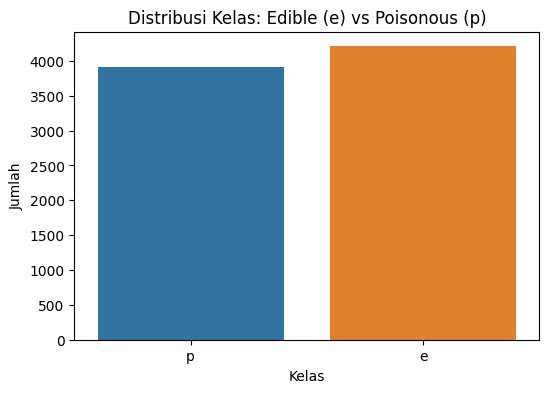

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='class', data=df, hue='class', legend=False)
plt.title("Distribusi Kelas: Edible (e) vs Poisonous (p)")
plt.xlabel("Kelas")
plt.ylabel("Jumlah")
plt.show()

Visualisasi 1: Distribusi Kelas Target (Edible vs Poisonous)

Count plot dipilih karena data bersifat kategorikal (bukan kontinu), sehingga histogram
numerik biasa tidak sesuai. Grafik ini menunjukkan seberapa seimbang jumlah sampel
edible dan poisonous dalam dataset.

Grafik di atas menunjukkan bahwa distribusi kelas cukup seimbang antara jamur edible dan
poisonous (sekitar 52% edible dan 48% poisonous), sehingga dataset ini tidak mengalami
masalah class imbalance yang signifikan untuk keperluan klasifikasi.

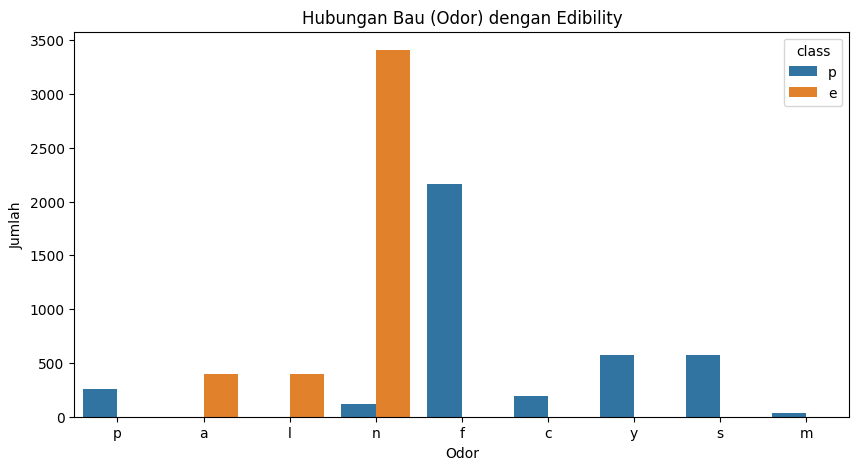

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='odor', hue='class', data=df)
plt.title("Hubungan Bau (Odor) dengan Edibility")
plt.xlabel("Odor")
plt.ylabel("Jumlah")
plt.show()

Visualisasi 2: Hubungan Odor (Bau) dengan Edibility

Count plot dengan pengelompokan (hue) berdasarkan `class` digunakan untuk melihat apakah
ada pola/hubungan antara fitur kategorikal `odor` dengan kelas target.

Grafik di atas menunjukkan bahwa beberapa jenis odor (misalnya foul, pungent, creosote)
hampir selalu berasosiasi dengan kelas poisonous, sementara odor tertentu seperti almond
dan anise cenderung berasosiasi dengan kelas edible. Ini mengindikasikan bahwa fitur
`odor` berpotensi menjadi salah satu fitur paling informatif untuk klasifikasi.

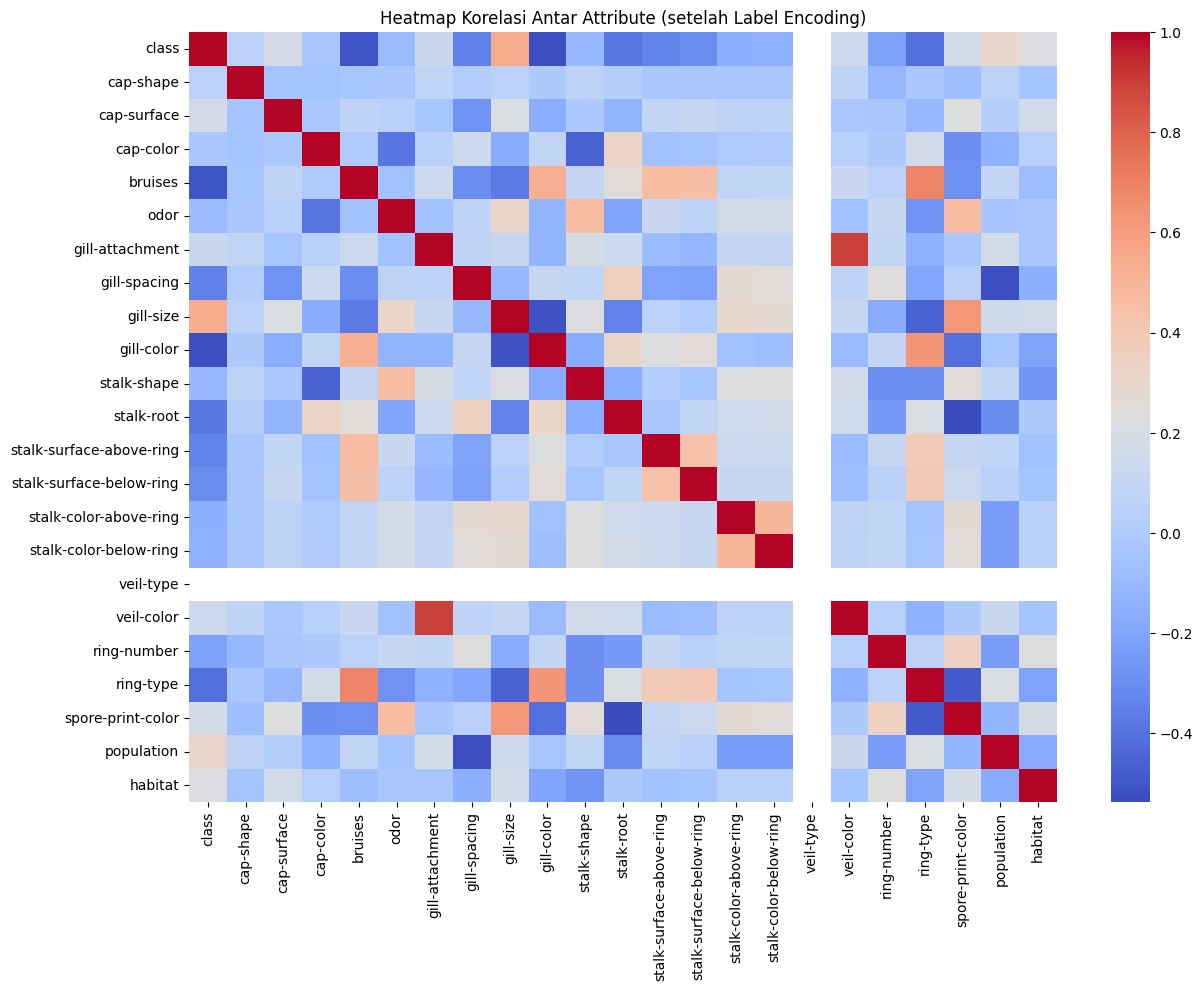

In [ ]:
plt.figure(figsize=(14,10))
corr = df_encoded.corr()
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Heatmap Korelasi Antar Attribute (setelah Label Encoding)")
plt.show()

Heatmap Korelasi Antar Attribute

Heatmap ini menampilkan koefisien korelasi antar seluruh attribute yang telah di-encode
menjadi angka. Nilai korelasi berkisar antara -1 hingga 1, di mana nilai mendekati 1 atau
-1 menandakan hubungan yang kuat, sementara mendekati 0 menandakan tidak ada hubungan
linear yang signifikan.

karena hasil encoding bersifat nominal (bukan ordinal), nilai
korelasi Pearson di sini hanya bersifat indikasi kasar, bukan hubungan matematis yang
sepenuhnya valid seperti pada data numerik kontinu asli. Pendekatan yang lebih tepat
secara statistik untuk data kategorikal-kategorikal sebenarnya adalah uji Chi-square
atau Cramér's V.

Dari heatmap di atas terlihat bahwa attribute seperti `gill-color`, `spore-print-color`,
dan `odor` memiliki korelasi yang relatif lebih tinggi terhadap `class` dibandingkan
attribute lain, mengindikasikan fitur-fitur ini berpotensi paling berpengaruh dalam
membedakan jamur edible dan poisonous.

In [ ]:
print("Jumlah nilai '?' per kolom:")
print((df == '?').sum()[(df == '?').sum() > 0])

Jumlah nilai '?' per kolom:
stalk-root    2480
dtype: int64


Berdasarkan dokumentasi dataset, nilai `?` pada kolom `stalk-root` merepresentasikan
data yang hilang (missing value), bukan kategori yang valid. Bagian ini mengecek
jumlah data hilang tersebut.

Terlihat bahwa hanya kolom `stalk-root` yang memiliki nilai hilang (`?`), sekitar
30% dari total data. Hal ini perlu dipertimbangkan pada tahap preprocessing
selanjutnya — apakah kolom ini akan dihapus, atau nilai hilangnya diimputasi.

Kesimpulan

Dataset Mushroom Classification terdiri dari 8.124 record dengan 23 attribute yang
seluruhnya bersifat kategorikal. Distribusi kelas target (edible vs poisonous) relatif
seimbang. Fitur `odor` dan `spore-print-color` menunjukkan pola hubungan yang kuat
dengan kelas target berdasarkan visualisasi dan heatmap korelasi, sehingga berpotensi
menjadi fitur penting dalam tahap pemodelan klasifikasi selanjutnya. Kolom `veil-type`
teridentifikasi tidak informatif (hanya 1 kategori) dan kolom `stalk-root` memiliki
missing value yang perlu ditangani pada tahap preprocessing.